<a href="https://colab.research.google.com/github/rpericharla1-cell/llm-data-quality-monitor/blob/main/01_data_profiler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1 — Workspace Setup

Step 1 🟢 Create GitHub repo
Step 2 🟢 Create Colab notebook
Step 3 🟢 Connect Colab to GitHub
Step 4 🟢 Store API keys in Colab Secrets
Step 5 🟢 Test both API keys work

In [4]:
!pip install anthropic google-generativeai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 15.4 MB/s eta 0:00:00


In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Create a permanent project folder in Drive
PROJECT_DIR = "/content/drive/MyDrive/llm_data_quality"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("✅ Google Drive mounted.")
print(f"✅ Project folder: {PROJECT_DIR}")
print("\nFiles currently in project folder:")
for f in os.listdir(PROJECT_DIR):
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.
✅ Project folder: /content/drive/MyDrive/llm_data_quality

Files currently in project folder:
  anomaly_examples.json


In [5]:
from google.colab import userdata

anthropic_key = userdata.get('ANTHROPIC_API_KEY')
gemini_key = userdata.get('GEMINI_API_KEY')

print("Anthropic key loaded:", anthropic_key[:10], "...")
print("Gemini key loaded:", gemini_key[:10], "...")

Anthropic key loaded: sk-ant-api ...
Gemini key loaded: AIzaSyCz1k ...


Phase 2 — Data (Synthetic Time Series)

Step 6 🟢 Design decisions (retail seasonality, 5 planted anomalies, synthetic approach)
Step 7 🟢 Generate 48-month baseline (trend + seasonality + noise)
Step 8 🟢 Plant the 5 anomalies (+ relabel patch for #5 → non_seasonal_dip)
Step 9 🟢 Visualize (overlaid by calendar month, 4 years on top of each other)
Step 10 🟢 Save dataset to CSV

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)  # so results are reproducible

# 48 months starting Jan 2021
dates = pd.date_range(start='2021-01-01', periods=48, freq='MS')

# 1. Base trend: slow growth over time
trend = np.linspace(50000, 80000, 48)

# 2. Seasonality: retail pattern (Nov/Dec spike, summer dip)
month_numbers = dates.month
seasonal_pattern = {
    1: -0.05, 2: -0.10, 3: -0.05, 4: 0.00, 5: 0.05, 6: -0.10,
    7: -0.15, 8: -0.10, 9: 0.00, 10: 0.10, 11: 0.35, 12: 0.55
}
seasonality = np.array([seasonal_pattern[m] for m in month_numbers]) * trend

# 3. Random noise
noise = np.random.normal(0, 1500, 48)

# Combine into final sales figure
sales = trend + seasonality + noise

df_sales = pd.DataFrame({'date': dates, 'sales': sales})
df_sales['sales'] = df_sales['sales'].round(2)
df_sales['is_anomaly'] = False
df_sales['anomaly_type'] = None

df_sales.head(15)

,date,sales,is_anomaly,anomaly_type
0,2021-01-01,48245.07,False,None
1,2021-02-01,45367.07,False,None
2,2021-03-01,49684.30,False,None
3,2021-04-01,54199.44,False,None
4,2021-05-01,54829.62,False,None
5,2021-06-01,47521.13,False,None
6,2021-07-01,48124.14,False,None
7,2021-08-01,50172.43,False,None
8,2021-09-01,54402.17,False,None
9,2021-10-01,62132.99,False,None


In [7]:
noise

array([  745.07122952,  -207.39645176,   971.53280715,  2284.54478461,
        -351.23006209,  -351.20543542,  2368.81922326,  1151.15209373,
        -704.2115789 ,   813.84006538,  -695.12653922,  -698.59463036,
         362.94340735, -2869.92036699, -2587.37674877,  -843.43129386,
       -1519.2466805 ,   471.37099889, -1362.03611328, -2118.455552  ,
        2198.47315338,  -338.66445073,   101.29230703, -2137.12227932,
        -816.57408679,   166.38388456, -1726.49036613,   563.54702752,
        -900.95803488,  -437.54062469,  -902.55991834,  2778.41727676,
         -20.24583711, -1586.56639343,  1233.81736815, -1831.26547496,
         313.29539251, -2939.50518582, -1992.27907335,   295.2918538 ,
        1107.69986999,   257.05242178,  -173.47242358,  -451.65554338,
       -2217.78298555, -1079.76631259,  -690.95815644,  1585.68333933])

In [8]:
# Make sure index aligns with month position (0-47)
df_sales = df_sales.reset_index(drop=True)

# --- Anomaly 1: Month 14 (index 13) — sudden unexplained spike ---
df_sales.loc[13, 'sales'] = df_sales.loc[13, 'sales'] * 1.8
df_sales.loc[13, 'is_anomaly'] = True
df_sales.loc[13, 'anomaly_type'] = 'sudden_spike'

# --- Anomaly 2: Month 23 (index 22) — sudden drop ---
df_sales.loc[22, 'sales'] = df_sales.loc[22, 'sales'] * 0.4
df_sales.loc[22, 'is_anomaly'] = True
df_sales.loc[22, 'anomaly_type'] = 'sudden_drop'

# --- Anomaly 3: Month 31 (index 30) — missing data ---
df_sales.loc[30, 'sales'] = np.nan
df_sales.loc[30, 'is_anomaly'] = True
df_sales.loc[30, 'anomaly_type'] = 'missing_data'

# --- Anomaly 4: Months 34-36 (index 33-35) — gradual drift down ---
df_sales.loc[33, 'sales'] = df_sales.loc[33, 'sales'] * 0.92
df_sales.loc[34, 'sales'] = df_sales.loc[34, 'sales'] * 0.83
df_sales.loc[35, 'sales'] = df_sales.loc[35, 'sales'] * 0.74
df_sales.loc[35, 'is_anomaly'] = True
df_sales.loc[35, 'anomaly_type'] = 'gradual_drift'

# --- Anomaly 5: Month 44 (index 43) — holiday spike that's too small ---
# November normally gets +35% boost — we'll cut that boost down to almost nothing
df_sales.loc[43, 'sales'] = df_sales.loc[43, 'sales'] * 0.65
df_sales.loc[43, 'is_anomaly'] = True
df_sales.loc[43, 'anomaly_type'] = 'non_seasonal_dip'

# Confirm all 5 are tagged
df_sales[df_sales['is_anomaly'] == True]

,date,sales,is_anomaly,anomaly_type
13,2022-02-01,89276.6880,True,sudden_spike
22,2022-11-01,34623.4960,True,sudden_drop
30,2023-07-01,NaN,True,missing_data
35,2023-12-01,81619.3286,True,gradual_drift
43,2024-08-01,45012.8055,True,non_seasonal_dip


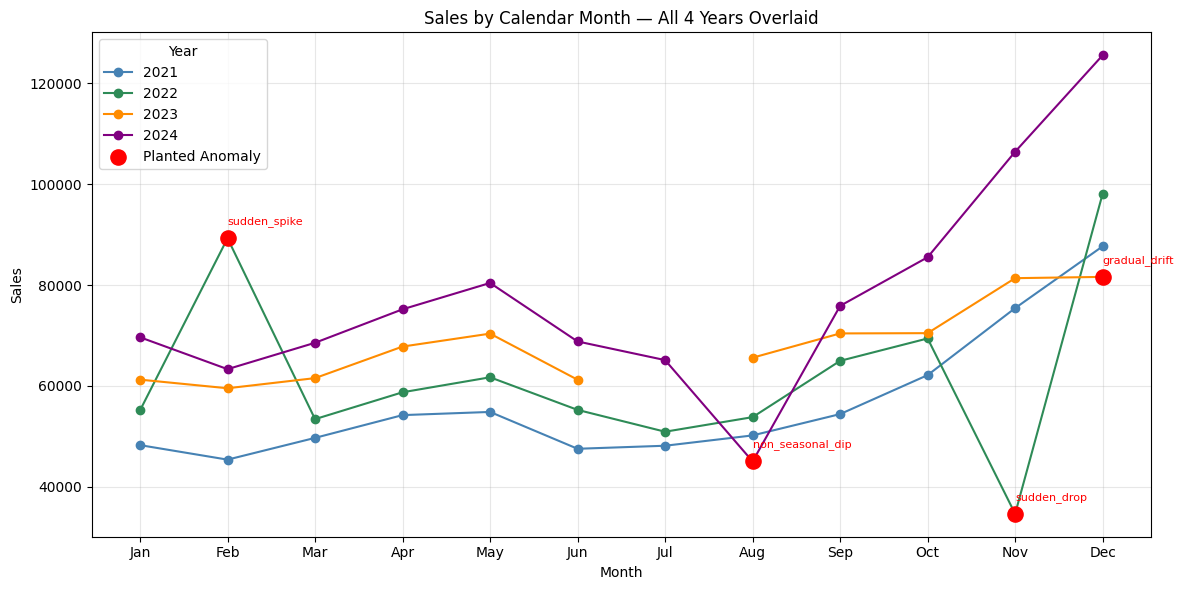

In [9]:
import matplotlib.pyplot as plt

# Add helper columns: which year, which calendar month
df_sales['year'] = df_sales['date'].dt.year
df_sales['month'] = df_sales['date'].dt.month

plt.figure(figsize=(12, 6))

colors = ['steelblue', 'seagreen', 'darkorange', 'purple']

# Plot one line per year, x-axis = calendar month (1-12)
for i, year in enumerate(sorted(df_sales['year'].unique())):
    year_data = df_sales[df_sales['year'] == year].sort_values('month')
    plt.plot(year_data['month'], year_data['sales'], marker='o',
              color=colors[i % len(colors)], label=str(year))

# Highlight anomalies in red, regardless of which year they fall in
anomaly_points = df_sales[df_sales['is_anomaly'] == True]
plt.scatter(anomaly_points['month'], anomaly_points['sales'],
            color='red', s=120, zorder=5, label='Planted Anomaly')

for _, row in anomaly_points.iterrows():
    plt.annotate(row['anomaly_type'], (row['month'], row['sales']),
                 textcoords="offset points", xytext=(0, 10), fontsize=8, color='red')

plt.title('Sales by Calendar Month — All 4 Years Overlaid')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
df_sales.to_csv('synthetic_sales_48mo.csv', index=False)
print("Saved! Preview:")
df_sales.head()

Saved! Preview:


,date,sales,is_anomaly,anomaly_type,year,month
0,2021-01-01,48245.07,False,None,2021,1
1,2021-02-01,45367.07,False,None,2021,2
2,2021-03-01,49684.30,False,None,2021,3
3,2021-04-01,54199.44,False,None,2021,4
4,2021-05-01,54829.62,False,None,2021,5


SECTION A — Core Pipeline (runs every time)
  Step 11 → Rolling baseline
  Step 12 → Seasonal baseline
  Step 13 → Deviation scores
  Step 14 → Candidate filter
  Step 15 → Install SDKs
  Step 16 → Google Drive + examples file
  Step 17 → Foundation examples + loader
  Step 18 → call_llm()
  Step 19 → build_anomaly_prompt()
  Step 21 → run_anomaly_pipeline()
  Step 22 → Run it

In [11]:
import numpy as np

df_sales = df_sales.sort_values('date').reset_index(drop=True)
df_sales['year'] = df_sales['date'].dt.year
df_sales['month'] = df_sales['date'].dt.month

df_sales['rolling_avg_12mo'] = df_sales['sales'].rolling(window=12, min_periods=6).mean()
df_sales['rolling_std_12mo'] = df_sales['sales'].rolling(window=12, min_periods=6).std()
df_sales['rolling_deviation'] = (
    (df_sales['sales'] - df_sales['rolling_avg_12mo']) /
    df_sales['rolling_std_12mo']
).round(2)

print("✅ Rolling baseline computed.")

✅ Rolling baseline computed.


In [12]:
seasonal_avgs, seasonal_stds = [], []

for idx in df_sales.index:
    current_month = df_sales.loc[idx, 'month']
    current_year  = df_sales.loc[idx, 'year']
    history = df_sales[
        (df_sales['month'] == current_month) &
        (df_sales['year']  < current_year)
    ]
    if len(history) == 0:
        seasonal_avgs.append(np.nan)
        seasonal_stds.append(np.nan)
    else:
        seasonal_avgs.append(history['sales'].mean())
        seasonal_stds.append(history['sales'].std())

df_sales['seasonal_avg'] = seasonal_avgs
df_sales['seasonal_std'] = seasonal_stds

print("✅ Seasonal baseline computed.")

✅ Seasonal baseline computed.


In [13]:
MIN_STD_PCT = 0.05

def safe_seasonal_deviation(row):
    if pd.isna(row['seasonal_avg']) or pd.isna(row['sales']):
        return np.nan
    std   = row['seasonal_std']
    floor = abs(row['seasonal_avg']) * MIN_STD_PCT
    if pd.isna(std) or std < floor:
        std = floor
    if std == 0:
        return np.nan
    return round((row['sales'] - row['seasonal_avg']) / std, 2)

df_sales['seasonal_deviation'] = df_sales.apply(safe_seasonal_deviation, axis=1)

print("✅ Deviation scores computed.")
df_sales[['date','sales','rolling_deviation','seasonal_deviation']].head(15)

✅ Deviation scores computed.


,date,sales,rolling_deviation,seasonal_deviation
0,2021-01-01,48245.070,NaN,NaN
1,2021-02-01,45367.070,NaN,NaN
2,2021-03-01,49684.300,NaN,NaN
3,2021-04-01,54199.440,NaN,NaN
4,2021-05-01,54829.620,NaN,NaN
5,2021-06-01,47521.130,-0.65,NaN
6,2021-07-01,48124.140,-0.45,NaN
7,2021-08-01,50172.430,0.12,NaN
8,2021-09-01,54402.170,1.20,NaN
9,2021-10-01,62132.990,2.16,NaN


In [14]:
def is_candidate_v2(row, threshold=1.5):
    if pd.isna(row['sales']):
        return True
    if row['month'] in [11, 12]:
        if pd.notna(row['seasonal_deviation']) and abs(row['seasonal_deviation']) >= threshold:
            return True
        return False
    if pd.notna(row['rolling_deviation']) and abs(row['rolling_deviation']) >= threshold:
        return True
    if pd.notna(row['seasonal_deviation']) and abs(row['seasonal_deviation']) >= threshold:
        return True
    return False

df_sales['is_candidate'] = df_sales.apply(is_candidate_v2, axis=1)

total      = len(df_sales)
candidates = df_sales['is_candidate'].sum()
print(f"✅ Candidate filter applied.")
print(f"   Total months:     {total}")
print(f"   Candidates:       {candidates}")
print(f"   Filtered out:     {total - candidates}")

✅ Candidate filter applied.
   Total months:     48
   Candidates:       30
   Filtered out:     18


In [15]:
!pip install anthropic google-generativeai -q

import anthropic
import google.generativeai as genai
from google.colab import userdata

anthropic_client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))
genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

print("✅ Both API clients configured.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Both API clients configured.


In [16]:
import os
import json
from google.colab import drive

drive.mount('/content/drive')

EXAMPLES_FILE = '/content/drive/MyDrive/llm_data_quality/anomaly_examples.json'
os.makedirs(os.path.dirname(EXAMPLES_FILE), exist_ok=True)

if not os.path.exists(EXAMPLES_FILE):
    initial_examples = [
        {
            "period": "synthetic-A",
            "history_desc": "steady 3% month-over-month growth for 18 months",
            "this_month_desc": "grew 3.4% over last month",
            "is_anomaly": False,
            "anomaly_type": "not_an_anomaly",
            "confidence": 12,
            "reasoning": "Growth rate almost identical to trend, trivial difference.",
            "source": "starter"
        },
        {
            "period": "synthetic-B",
            "history_desc": "steady 3% month-over-month growth for 18 months",
            "this_month_desc": "grew 6.1% over last month, roughly double the normal rate",
            "is_anomaly": True,
            "anomaly_type": "sudden_spike",
            "confidence": 58,
            "reasoning": "Notably faster than trend but not extreme. Moderate confidence.",
            "source": "starter"
        },
        {
            "period": "synthetic-C",
            "history_desc": "steady 3% month-over-month growth for 18 months",
            "this_month_desc": "dropped 22%, no prior month ever dropped more than 2%",
            "is_anomaly": True,
            "anomaly_type": "sudden_drop",
            "confidence": 93,
            "reasoning": "Sharp reversal with no precedent in history. Very high confidence.",
            "source": "starter"
        },
        {
            "period": "synthetic-D",
            "history_desc": "December always 40-50% above average for 3 prior years",
            "this_month_desc": "December is 45% above average, consistent with prior years",
            "is_anomaly": False,
            "anomaly_type": "not_an_anomaly",
            "confidence": 8,
            "reasoning": "Spike matches prior Decembers closely. Extremely low confidence.",
            "source": "starter"
        },
        {
            "period": "synthetic-E",
            "history_desc": "December always 40-50% above average for 3 prior years",
            "this_month_desc": "December only 12% above average, far below seasonal boost",
            "is_anomaly": True,
            "anomaly_type": "weak_seasonal_performance",
            "confidence": 71,
            "reasoning": "December should spike 40-50% but only spiked 12%. Pattern broke.",
            "source": "starter"
        }
    ]
    with open(EXAMPLES_FILE, 'w') as f:
        json.dump(initial_examples, f, indent=2)
    print(f"✅ Created examples file with 5 starter examples.")
else:
    with open(EXAMPLES_FILE, 'r') as f:
        existing = json.load(f)
    print(f"✅ Loaded existing examples file — {len(existing)} examples found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded existing examples file — 6 examples found.


In [17]:
FOUNDATION_EXAMPLES = [
    {
        "label": "A",
        "history_desc": "steady 3% month-over-month growth for 18 months",
        "this_month_desc": "grew 3.4% over last month (within normal range)",
        "is_anomaly": False,
        "anomaly_type": "not_an_anomaly",
        "confidence": 12,
        "reasoning": "Growth rate almost identical to trend, trivial 0.4 point difference."
    },
    {
        "label": "B",
        "history_desc": "steady 3% month-over-month growth for 18 months",
        "this_month_desc": "grew 6.1% over last month, roughly double the normal rate",
        "is_anomaly": True,
        "anomaly_type": "sudden_spike",
        "confidence": 58,
        "reasoning": "Notably faster than trend but not extreme. Moderate confidence."
    },
    {
        "label": "C",
        "history_desc": "steady 3% month-over-month growth for 18 months",
        "this_month_desc": "dropped 22%, no prior month ever dropped more than 2%",
        "is_anomaly": True,
        "anomaly_type": "sudden_drop",
        "confidence": 93,
        "reasoning": "Sharp reversal with no precedent in history. Very high confidence."
    },
    {
        "label": "D",
        "history_desc": "December always 40-50% above average for 3 prior years",
        "this_month_desc": "December is 45% above average, consistent with prior years",
        "is_anomaly": False,
        "anomaly_type": "not_an_anomaly",
        "confidence": 8,
        "reasoning": "Spike matches prior Decembers closely. Extremely low confidence."
    },
    {
        "label": "E",
        "history_desc": "December always 40-50% above average for 3 prior years",
        "this_month_desc": "December only 12% above average, far below seasonal boost",
        "is_anomaly": True,
        "anomaly_type": "weak_seasonal_performance",
        "confidence": 71,
        "reasoning": "December should spike 40-50% but only spiked 12%. Pattern broke."
    },
]

def load_few_shot_examples():
    all_examples = []

    # Always load foundation examples first
    for ex in FOUNDATION_EXAMPLES:
        all_examples.append({
            "label":          ex["label"],
            "history_desc":   ex["history_desc"],
            "this_month_desc":ex["this_month_desc"],
            "is_anomaly":     ex["is_anomaly"],
            "anomaly_type":   ex.get("anomaly_type", "not_an_anomaly"),
            "confidence":     ex["confidence"],
            "reasoning":      ex["reasoning"],
            "source":         "foundation"
        })

    # Then load human-added examples from Drive
    drive_examples = []
    if os.path.exists(EXAMPLES_FILE):
        try:
            with open(EXAMPLES_FILE, 'r') as f:
                drive_examples = json.load(f)
            drive_examples = [
                e for e in drive_examples
                if not e.get('period', '').startswith('synthetic')
            ]
        except Exception as e:
            print(f"⚠️ Could not load Drive examples: {e}")

    for i, ex in enumerate(drive_examples):
        label = chr(65 + len(FOUNDATION_EXAMPLES) + i)
        all_examples.append({
            "label":          label,
            "history_desc":   ex.get("history_desc", ""),
            "this_month_desc":ex.get("this_month_desc", ""),
            "is_anomaly":     ex.get("is_anomaly", False),
            "anomaly_type":   ex.get("anomaly_type", "unknown"),
            "confidence":     ex.get("confidence", 50),
            "reasoning":      ex.get("reasoning", ""),
            "source":         f"human observation ({ex.get('period','unknown')})"
        })

    formatted = f"""Below are {len(all_examples)} calibrated anomaly judgment examples \
({len(FOUNDATION_EXAMPLES)} foundation + {len(drive_examples)} human observations).
Study these carefully — notice confidence scores are specific to each case,
not rounded defaults like 25, 50, 75:

"""
    for ex in all_examples:
        formatted += f"""EXAMPLE {ex['label']} [source: {ex['source']}]:
History pattern: {ex['history_desc']}
This month: {ex['this_month_desc']}
Correct verdict:
  - is_anomaly: {str(ex['is_anomaly']).lower()}
  - anomaly_type: {ex['anomaly_type']}
  - confidence: {ex['confidence']}
  - reasoning: {ex['reasoning']}

"""
    formatted += """When forming your verdict, find the example that most resembles
this case, then adjust confidence up or down based on how much more
or less extreme this case is compared to that example.
"""
    return formatted, len(all_examples), len(drive_examples)

few_shot_text, total, drive_count = load_few_shot_examples()
print(f"✅ Few-shot loader ready.")
print(f"   Foundation examples: {len(FOUNDATION_EXAMPLES)}")
print(f"   Human observations:  {drive_count}")
print(f"   Total in prompt:     {total}")

✅ Few-shot loader ready.
   Foundation examples: 5
   Human observations:  1
   Total in prompt:     6


In [18]:
import time

def call_llm(prompt, model="claude", verbose=False):
    start_time = time.time()

    if model == "claude":
        response = anthropic_client.messages.create(
            model="claude-sonnet-4-5-20250929",
            max_tokens=1000,
            messages=[{"role": "user", "content": prompt}]
        )
        raw_text      = response.content[0].text
        input_tokens  = response.usage.input_tokens
        output_tokens = response.usage.output_tokens

    elif model == "gemini":
        gemini_model = genai.GenerativeModel("gemini-2.0-flash")
        response     = gemini_model.generate_content(prompt)
        raw_text      = response.text
        input_tokens  = response.usage_metadata.prompt_token_count
        output_tokens = response.usage_metadata.candidates_token_count
    else:
        raise ValueError("model must be 'claude' or 'gemini'")

    elapsed    = round(time.time() - start_time, 2)
    clean_text = raw_text.strip().replace("```json","").replace("```","").strip()

    try:
        parsed = json.loads(clean_text)
    except json.JSONDecodeError:
        parsed = {"error": "Failed to parse JSON", "raw_response": raw_text}

    parsed["_meta"] = {
        "model":           model,
        "input_tokens":    input_tokens,
        "output_tokens":   output_tokens,
        "elapsed_seconds": elapsed
    }

    if verbose:
        print(f"[{model}] {elapsed}s | in:{input_tokens} out:{output_tokens} tokens")

    return parsed

print("✅ call_llm() ready.")

✅ call_llm() ready.


In [19]:
def build_anomaly_prompt(df, row_index):
    row = df.loc[row_index]

    history      = df.loc[:row_index, ['date', 'sales']].copy()
    history_list = [
        f"{r['date'].strftime('%Y-%m')}: {r['sales'] if pd.notna(r['sales']) else 'MISSING'}"
        for _, r in history.iterrows()
    ]
    full_history_str = "\n".join(history_list)
    value_str        = row['sales'] if pd.notna(row['sales']) else "MISSING"

    few_shot_block, _, _ = load_few_shot_examples()

    prompt = f"""You are a data quality analyst reviewing monthly time series data.
You are NOT told what "normal" looks like — infer trend and seasonality yourself.

IMPORTANT: A new all-time high or low is NOT automatically anomalous if the metric
has been steadily growing or shrinking. Only flag a month if it clearly BREAKS the
established trajectory — not merely because it is a new extreme.

{few_shot_block}

FULL HISTORY (oldest to newest):
{full_history_str}

MONTH BEING REVIEWED: {row['date'].strftime('%Y-%m')}
Value: {value_str}

STATISTICAL SIGNALS (reference only — use your own judgment too):
- Rolling 12-month average: {row['rolling_avg_12mo']}, deviation: {row['rolling_deviation']} std devs
- Same-month historical average: {row['seasonal_avg']}, deviation: {row['seasonal_deviation']} std devs

TASK:
1. Infer the trend and seasonal pattern from the history above.
2. Which example above does this case most resemble?
3. Does this month fit the trajectory or break from it?
4. Is this a genuine anomaly? Only flag if it clearly breaks the trajectory.
5. Classify if anomalous: sudden_spike / sudden_drop / missing_data /
   gradual_drift / weak_seasonal_performance / other
6. Severity: critical / high / medium / low / not_an_anomaly
7. Confidence: 0-100, anchored to the closest example, adjusted for magnitude.
8. Plain-English explanation for a non-technical stakeholder.

Respond ONLY in this JSON format:
{{
  "inferred_pattern": "...",
  "closest_example": "example letter + one sentence why",
  "fits_trajectory": true/false,
  "is_anomaly": true/false,
  "anomaly_type": "...",
  "severity": "...",
  "confidence": 0-100,
  "explanation": "..."
}}"""
    return prompt

print("✅ build_anomaly_prompt() ready.")

✅ build_anomaly_prompt() ready.


In [20]:
def propose_explanation_for_feedback(period_str, feedback_type,
                                      current_system_verdict=None):
    year  = int(period_str[:4])
    month = int(period_str[4:6])
    match = df_sales[(df_sales['year'] == year) & (df_sales['month'] == month)]

    if len(match) == 0:
        print(f"No data found for {period_str}.")
        return None

    row_index = match.index[0]
    row       = df_sales.loc[row_index]

    history      = df_sales.loc[:row_index, ['date', 'sales']].copy()
    history_list = [
        f"{r['date'].strftime('%Y-%m')}: {r['sales'] if pd.notna(r['sales']) else 'MISSING'}"
        for _, r in history.iterrows()
    ]
    full_history_str = "\n".join(history_list)
    value_str        = row['sales'] if pd.notna(row['sales']) else "MISSING"

    system_context = ""
    if current_system_verdict is not None:
        system_context = f"""
SYSTEM'S ORIGINAL VERDICT:
- is_anomaly: {current_system_verdict.get('is_anomaly')}
- anomaly_type: {current_system_verdict.get('anomaly_type')}
- confidence: {current_system_verdict.get('confidence')}
"""

    if feedback_type == "false_negative":
        human_position = "The human believes this SHOULD have been flagged but was missed."
        task_focus     = "Propose why this month likely IS anomalous."
    elif feedback_type == "false_positive":
        human_position = "The human believes this should NOT have been flagged."
        task_focus     = "Propose why this month is likely NOT anomalous."
    else:
        raise ValueError("feedback_type must be 'false_negative' or 'false_positive'")

    flag_prompt = f"""A human reviewer has flagged this month. {human_position}

FULL HISTORY:
{full_history_str}

FLAGGED MONTH: {row['date'].strftime('%Y-%m')}
Value: {value_str}
{system_context}
TASK: {task_focus}
Write a corrected verdict that can be reused as a teaching example.

Respond ONLY in this JSON format:
{{
  "proposed_is_anomaly": true/false,
  "proposed_anomaly_type": "...",
  "proposed_severity": "...",
  "proposed_confidence": 0-100,
  "proposed_reasoning": "...",
  "history_desc": "generalized description of pattern (no specific dates/amounts)",
  "this_month_desc": "generalized description of what makes this month notable"
}}"""

    proposal = call_llm(flag_prompt, model="claude", verbose=True)
    proposal['period']        = period_str
    proposal['actual_value']  = value_str
    proposal['feedback_type'] = feedback_type

    print(f"\n{'='*60}")
    print(f"PROPOSED CORRECTION FOR {period_str} [{feedback_type.upper()}]")
    print(f"{'='*60}")
    print(f"Anomaly?:   {proposal.get('proposed_is_anomaly')}")
    print(f"Type:       {proposal.get('proposed_anomaly_type')}")
    print(f"Severity:   {proposal.get('proposed_severity')}")
    print(f"Confidence: {proposal.get('proposed_confidence')}")
    print(f"Reasoning:  {proposal.get('proposed_reasoning')}")
    print(f"\nHistory pattern:    {proposal.get('history_desc')}")
    print(f"This month pattern: {proposal.get('this_month_desc')}")
    print(f"{'='*60}")
    print("✅ If this looks right: save_proposed_example(proposal)")
    print("✏️  To correct it: edit proposal dict fields, then save.")

    return proposal


def save_proposed_example(proposal):
    def get_field(d, *keys, fallback="unknown"):
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
        return fallback

    new_example = {
        "period":          get_field(proposal, 'period',              fallback="unknown"),
        "history_desc":    get_field(proposal, 'history_desc',        fallback=""),
        "this_month_desc": get_field(proposal, 'this_month_desc',     fallback=""),
        "is_anomaly":      get_field(proposal, 'proposed_is_anomaly', 'is_anomaly', fallback=False),
        "anomaly_type":    get_field(proposal, 'proposed_anomaly_type','anomaly_type',fallback="unknown"),
        "confidence":      get_field(proposal, 'proposed_confidence', 'confidence', fallback=50),
        "reasoning":       get_field(proposal, 'proposed_reasoning',  'reasoning',  fallback=""),
        "source":          get_field(proposal, 'feedback_type',       fallback="manual_flag")
    }

    print("\nAbout to save:")
    for k, v in new_example.items():
        print(f"  {k}: {v}")

    if not os.path.exists(EXAMPLES_FILE):
        print(f"\n⚠️ {EXAMPLES_FILE} not found. Run Step 16 first.")
        return None

    with open(EXAMPLES_FILE, 'r') as f:
        examples = json.load(f)

    before = len(examples)
    examples = [e for e in examples if e.get('period') != new_example['period']]
    if len(examples) < before:
        print(f"Replaced existing entry for {new_example['period']}")

    examples.append(new_example)

    with open(EXAMPLES_FILE, 'w') as f:
        json.dump(examples, f, indent=2)

    print(f"\n✅ Saved. Total examples in Drive: {len(examples)}")
    return examples


def show_examples_status():
    print("="*60)
    print("FEW-SHOT EXAMPLES STATUS")
    print("="*60)

    print(f"\n📌 FOUNDATION ({len(FOUNDATION_EXAMPLES)} — always present):")
    for ex in FOUNDATION_EXAMPLES:
        tag = "🔴 anomaly" if ex['is_anomaly'] else "✅ normal"
        print(f"   {ex['label']}: {tag} | confidence: {ex['confidence']} | {ex.get('anomaly_type','not_an_anomaly')}")

    print(f"\n👤 HUMAN-ADDED (from Google Drive):")
    if not os.path.exists(EXAMPLES_FILE):
        print("   ⚠️ File not found — run Step 16.")
        return

    with open(EXAMPLES_FILE, 'r') as f:
        all_drive = json.load(f)

    human = [e for e in all_drive if not e.get('period','').startswith('synthetic')]

    if not human:
        print("   None yet.")
    else:
        for ex in human:
            tag = "🔴 anomaly" if ex.get('is_anomaly') else "✅ normal"
            print(f"   {ex['period']}: {tag} | confidence: {ex.get('confidence','?')} | "
                  f"{ex.get('anomaly_type','?')} | source: {ex.get('source','?')}")

    print(f"\n{'─'*60}")
    print(f"   Foundation:      {len(FOUNDATION_EXAMPLES)}")
    print(f"   Human-added:     {len(human)}")
    print(f"   TOTAL IN PROMPT: {len(FOUNDATION_EXAMPLES) + len(human)}")
    print("="*60)
    print("\n💡 To add feedback:")
    print("   proposal = propose_explanation_for_feedback('YYYYMM', 'false_negative')")
    print("   save_proposed_example(proposal)")

print("✅ Feedback functions ready.")
show_examples_status()

✅ Feedback functions ready.
FEW-SHOT EXAMPLES STATUS

📌 FOUNDATION (5 — always present):
   A: ✅ normal | confidence: 12 | not_an_anomaly
   B: 🔴 anomaly | confidence: 58 | sudden_spike
   C: 🔴 anomaly | confidence: 93 | sudden_drop
   D: ✅ normal | confidence: 8 | not_an_anomaly
   E: 🔴 anomaly | confidence: 71 | weak_seasonal_performance

👤 HUMAN-ADDED (from Google Drive):
   202411: ✅ normal | confidence: 85 | none | source: false_positive

────────────────────────────────────────────────────────────
   Foundation:      5
   Human-added:     1
   TOTAL IN PROMPT: 6

💡 To add feedback:
   proposal = propose_explanation_for_feedback('YYYYMM', 'false_negative')
   save_proposed_example(proposal)


In [21]:
def run_anomaly_pipeline(df, model="claude", confidence_threshold=50, verbose=True):
    start_time = time.time()

    if verbose:
        print("="*60)
        print("LLM DATA QUALITY PIPELINE")
        print("="*60)

    # Recompute baselines freshly
    df = df.sort_values('date').reset_index(drop=True)
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month

    df['rolling_avg_12mo'] = df['sales'].rolling(window=12, min_periods=6).mean()
    df['rolling_std_12mo'] = df['sales'].rolling(window=12, min_periods=6).std()
    df['rolling_deviation'] = (
        (df['sales'] - df['rolling_avg_12mo']) /
        df['rolling_std_12mo']
    ).round(2)

    seasonal_avgs, seasonal_stds = [], []
    for idx in df.index:
        cm = df.loc[idx, 'month']
        cy = df.loc[idx, 'year']
        h  = df[(df['month'] == cm) & (df['year'] < cy)]
        seasonal_avgs.append(h['sales'].mean() if len(h) > 0 else np.nan)
        seasonal_stds.append(h['sales'].std()  if len(h) > 0 else np.nan)

    df['seasonal_avg'] = seasonal_avgs
    df['seasonal_std'] = seasonal_stds
    df['seasonal_deviation'] = df.apply(safe_seasonal_deviation, axis=1)

    df['is_candidate'] = df.apply(is_candidate_v2, axis=1)
    candidate_indices  = df[df['is_candidate'] == True].index.tolist()

    if verbose:
        print(f"\n[1/3] Statistical baseline computed.")
        print(f"[2/3] Candidates: {len(candidate_indices)} of {len(df)} months.")
        print(f"[3/3] Sending to {model}...\n")

    results = []
    for i, idx in enumerate(candidate_indices):
        if verbose:
            print(f"  [{i+1}/{len(candidate_indices)}] {df.loc[idx,'date'].strftime('%Y-%m')}...", end=" ")

        prompt = build_anomaly_prompt(df, idx)
        result = call_llm(prompt, model=model, verbose=False)
        result['date']       = df.loc[idx, 'date'].strftime('%Y-%m')
        result['month_index']= idx
        results.append(result)

        if verbose:
            status = "🔴 ANOMALY" if result.get('is_anomaly') else "✅ normal"
            print(f"{status} (confidence: {result.get('confidence','?')})")

        time.sleep(1)

    results_df = pd.DataFrame(results)
    results_df['input_tokens']    = results_df['_meta'].apply(lambda m: m['input_tokens'])
    results_df['output_tokens']   = results_df['_meta'].apply(lambda m: m['output_tokens'])
    results_df['elapsed_seconds'] = results_df['_meta'].apply(lambda m: m['elapsed_seconds'])

    total_input  = results_df['input_tokens'].sum()
    total_output = results_df['output_tokens'].sum()
    total_cost   = (total_input  / 1_000_000 * 3.00) + \
                   (total_output / 1_000_000 * 15.00)

    findings_df = results_df[
        (results_df['is_anomaly'] == True) &
        (results_df['confidence'] >= confidence_threshold)
    ].copy()

    summary = {
        "total_months":          len(df),
        "candidates_reviewed":   len(candidate_indices),
        "months_skipped":        len(df) - len(candidate_indices),
        "model_used":            model,
        "confidence_threshold":  confidence_threshold,
        "total_findings":        len(findings_df),
        "severity_counts":       findings_df['severity'].value_counts().to_dict() if len(findings_df) > 0 else {},
        "total_input_tokens":    total_input,
        "total_output_tokens":   total_output,
        "estimated_cost_usd":    round(total_cost, 4),
        "total_runtime_seconds": round(time.time() - start_time, 1),
        "few_shot_examples_used":len(FOUNDATION_EXAMPLES)
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"PIPELINE COMPLETE")
        print(f"{'='*60}")
        print(f"  Months reviewed:  {summary['candidates_reviewed']} of {summary['total_months']}")
        print(f"  Findings:         {summary['total_findings']} (confidence >= {confidence_threshold})")
        print(f"  Severity:         {summary['severity_counts']}")
        print(f"  Cost:             ${summary['estimated_cost_usd']}")
        print(f"  Runtime:          {summary['total_runtime_seconds']}s")
        print(f"{'='*60}")

    return results_df, findings_df, summary

print("✅ run_anomaly_pipeline() ready.")

✅ run_anomaly_pipeline() ready.


In [22]:
results_df, findings_df, summary = run_anomaly_pipeline(
    df_sales,
    model="claude",
    confidence_threshold=50,
    verbose=True
)

LLM DATA QUALITY PIPELINE

[1/3] Statistical baseline computed.
[2/3] Candidates: 30 of 48 months.
[3/3] Sending to claude...

  [1/30] 2021-10... 🔴 ANOMALY (confidence: 64)
  [2/30] 2022-01... 🔴 ANOMALY (confidence: 78)
  [3/30] 2022-02... 🔴 ANOMALY (confidence: 78)
  [4/30] 2022-03... ✅ normal (confidence: 14)
  [5/30] 2022-04... ✅ normal (confidence: 18)
  [6/30] 2022-05... ✅ normal (confidence: 18)
  [7/30] 2022-06... ✅ normal (confidence: 18)
  [8/30] 2022-09... ✅ normal (confidence: 18)
  [9/30] 2022-10... ✅ normal (confidence: 18)
  [10/30] 2022-11... 🔴 ANOMALY (confidence: 96)
  [11/30] 2022-12... ✅ normal (confidence: 14)
  [12/30] 2023-01... ✅ normal (confidence: 18)
  [13/30] 2023-03... ✅ normal (confidence: 18)
  [14/30] 2023-04... ✅ normal (confidence: 18)
  [15/30] 2023-05... ✅ normal (confidence: 18)
  [16/30] 2023-06... ✅ normal (confidence: 9)
  [17/30] 2023-07... 🔴 ANOMALY (confidence: 88)
  [18/30] 2023-08... 🔴 ANOMALY (confidence: 64)
  [19/30] 2023-12... 🔴 ANOMALY 

SECTION B — Review Results (run after pipeline)
  → Look at results_df
  → Check findings_df
  → Use show_examples_status() to see example count

In [23]:
# Section B — Cell 1: Full Results Table
display_cols = [
    'date', 'is_anomaly', 'fits_trajectory', 'closest_example',
    'anomaly_type', 'severity', 'confidence'
]
print(f"Total candidates reviewed: {len(results_df)}")
print(f"Flagged as anomalies: {results_df['is_anomaly'].sum()}")
print()
results_df[display_cols]

Total candidates reviewed: 30
Flagged as anomalies: 11



,date,is_anomaly,fits_trajectory,closest_example,anomaly_type,severity,confidence
0,2021-10,True,False,Example B - this month shows acceleration beyo...,sudden_spike,medium,64
1,2022-01,True,False,Example E - like a December that fails to spik...,sudden_drop,high,78
2,2022-02,True,False,Example B - this resembles a sudden spike that...,sudden_spike,high,78
3,2022-03,False,True,Example D - this resembles a return to normal ...,not_an_anomaly,not_an_anomaly,14
4,2022-04,False,True,Example A - growth rate within normal range af...,not_an_anomaly,not_an_anomaly,18
5,2022-05,False,True,Example A - the value continues normal growth ...,not_an_anomaly,not_an_anomaly,18
6,2022-06,False,True,Example A - value is within normal range follo...,not_an_anomaly,not_an_anomaly,18
7,2022-09,False,True,Example A - This month represents normal progr...,not_an_anomaly,not_an_anomaly,18
8,2022-10,False,True,Example A - this represents normal continuatio...,not_an_anomaly,not_an_anomaly,18
9,2022-11,True,False,"Example C - like the sharp reversal case, this...",sudden_drop,critical,96


In [24]:
# Section B — Cell 2: Confirmed Findings
print(f"Confirmed findings (confidence >= {summary['confidence_threshold']}):")
print(f"Total: {len(findings_df)}")
print()

findings_display = findings_df[[
    'date', 'anomaly_type', 'severity',
    'confidence', 'explanation'
]].copy()

# Truncate explanation for readability
findings_display['explanation'] = findings_display['explanation'].str[:120] + "..."

findings_display

Confirmed findings (confidence >= 50):
Total: 11



,date,anomaly_type,severity,confidence,explanation
0,2021-10,sudden_spike,medium,64,"October 2021 reached 62,133, which is approxim..."
1,2022-01,sudden_drop,high,78,January 2022 dropped 37% from December 2021 (f...
2,2022-02,sudden_spike,high,78,"February 2022 jumped to $89,277, which is high..."
9,2022-11,sudden_drop,critical,96,November 2022 shows a severe anomaly. Based on...
16,2023-07,missing_data,high,88,July 2023 data is completely missing. Based on...
17,2023-08,sudden_spike,medium,64,"August 2023 at 65,587 is significantly higher ..."
18,2023-12,weak_seasonal_performance,medium,67,December has historically been the strongest m...
19,2024-01,weak_seasonal_performance,medium,67,January 2024 shows an unusual pattern compared...
25,2024-08,sudden_drop,critical,89,"August 2024 dropped to 45,013, a 44% decline f..."
26,2024-09,sudden_spike,medium,64,"September 2024 (75,867) is unusually high comp..."


In [25]:
# Section B — Cell 3: Severity Breakdown
print("SEVERITY BREAKDOWN")
print("="*40)
if len(findings_df) > 0:
    for severity in ['critical', 'high', 'medium', 'low']:
        count = len(findings_df[findings_df['severity'] == severity])
        bar   = "█" * count
        print(f"  {severity.upper():<10} {bar} ({count})")
else:
    print("  No findings above confidence threshold.")

SEVERITY BREAKDOWN
  CRITICAL   ██ (2)
  HIGH       ████ (4)
  MEDIUM     █████ (5)
  LOW         (0)


In [26]:
# Section B — Cell 4: Cost Summary
print("PIPELINE COST SUMMARY")
print("="*40)
print(f"  Model used:          {summary['model_used']}")
print(f"  Months in dataset:   {summary['total_months']}")
print(f"  Candidates reviewed: {summary['candidates_reviewed']}")
print(f"  Months skipped:      {summary['months_skipped']}")
print(f"  LLM calls made:      {summary['candidates_reviewed']}")
print(f"  Total input tokens:  {summary['total_input_tokens']:,}")
print(f"  Total output tokens: {summary['total_output_tokens']:,}")
print(f"  Estimated cost:      ${summary['estimated_cost_usd']}")
print(f"  Runtime:             {summary['total_runtime_seconds']}s")
print(f"  Few-shot examples:   {summary['few_shot_examples_used']}")

PIPELINE COST SUMMARY
  Model used:          claude
  Months in dataset:   48
  Candidates reviewed: 30
  Months skipped:      18
  LLM calls made:      30
  Total input tokens:  51,174
  Total output tokens: 10,906
  Estimated cost:      $0.3171
  Runtime:             321.2s
  Few-shot examples:   5


In [27]:
# Section B — Cell 5: Examples Status
show_examples_status()

FEW-SHOT EXAMPLES STATUS

📌 FOUNDATION (5 — always present):
   A: ✅ normal | confidence: 12 | not_an_anomaly
   B: 🔴 anomaly | confidence: 58 | sudden_spike
   C: 🔴 anomaly | confidence: 93 | sudden_drop
   D: ✅ normal | confidence: 8 | not_an_anomaly
   E: 🔴 anomaly | confidence: 71 | weak_seasonal_performance

👤 HUMAN-ADDED (from Google Drive):
   202411: ✅ normal | confidence: 85 | none | source: false_positive

────────────────────────────────────────────────────────────
   Foundation:      5
   Human-added:     1
   TOTAL IN PROMPT: 6

💡 To add feedback:
   proposal = propose_explanation_for_feedback('YYYYMM', 'false_negative')
   save_proposed_example(proposal)


In [28]:
# Merge ground truth back into results_df
ground_truth = df_sales[['date', 'is_anomaly', 'anomaly_type']].copy()
ground_truth['date'] = ground_truth['date'].dt.strftime('%Y-%m')
ground_truth = ground_truth.rename(columns={
    'is_anomaly':   'actually_planted',
    'anomaly_type': 'actual_anomaly_type'
})

results_df = results_df.merge(ground_truth, on='date', how='left')

print(f"✅ Ground truth merged.")
print(f"   Planted anomalies in results: {results_df['actually_planted'].sum()}")

✅ Ground truth merged.
   Planted anomalies in results: 5


In [29]:
# Section B — Cell 6: Accuracy Check
# Only works if results_df has 'actually_planted' column from a scoring run
if 'actually_planted' in results_df.columns:
    planted      = results_df[results_df['actually_planted'] == True]
    caught       = planted[planted['is_anomaly'] == True]
    false_pos    = results_df[
        (results_df['actually_planted'] == False) &
        (results_df['is_anomaly'] == True)
    ]

    print("ACCURACY SCORECARD")
    print("="*40)
    print(f"  Planted anomalies:     {len(planted)}")
    print(f"  Correctly caught:      {len(caught)} / {len(planted)}")
    print(f"  Recall:                {len(caught)/len(planted)*100:.0f}%")
    print(f"  False positives:       {len(false_pos)} of {len(results_df)-len(planted)} normal months")
    print(f"  False positive rate:   {len(false_pos)/(len(results_df)-len(planted))*100:.0f}%")
    print()
    print("PLANTED ANOMALIES DETAIL:")
    print("-"*40)
    for _, row in planted.iterrows():
        status = "✅ CAUGHT" if row['is_anomaly'] else "❌ MISSED"
        print(f"  {row['date']} | {row['actual_anomaly_type']:<25} | {status} | confidence: {row.get('confidence','?')}")
else:
    print("ℹ️  No ground truth column found.")
    print("   This is normal when running on a real dataset.")
    print("   Use findings_df to manually review results instead.")

ACCURACY SCORECARD
  Planted anomalies:     5
  Correctly caught:      5 / 5
  Recall:                100%
  False positives:       6 of 25 normal months
  False positive rate:   24%

PLANTED ANOMALIES DETAIL:
----------------------------------------
  2022-02 | sudden_spike              | ✅ CAUGHT | confidence: 78
  2022-11 | sudden_drop               | ✅ CAUGHT | confidence: 96
  2023-07 | missing_data              | ✅ CAUGHT | confidence: 88
  2023-12 | gradual_drift             | ✅ CAUGHT | confidence: 67
  2024-08 | non_seasonal_dip          | ✅ CAUGHT | confidence: 89


In [30]:
# Section C — Cell 1: Identify false positives
false_positives = results_df[
    (results_df['actually_planted'] == False) &
    (results_df['is_anomaly'] == True)
][['date', 'anomaly_type', 'severity', 'confidence', 'explanation']]

print(f"FALSE POSITIVES ({len(false_positives)} months wrongly flagged)")
print("="*60)
for _, row in false_positives.iterrows():
    print(f"\n  📅 {row['date']}")
    print(f"     Flagged as: {row['anomaly_type']} | severity: {row['severity']} | confidence: {row['confidence']}")
    print(f"     Reason given: {str(row['explanation'])[:120]}...")
print("\nTo correct any of these, use Section C Cell 2.")

FALSE POSITIVES (6 months wrongly flagged)

  📅 2021-10
     Flagged as: sudden_spike | severity: medium | confidence: 64
     Reason given: October 2021 reached 62,133, which is approximately 14% higher than any previous month in our 10-month history. While th...

  📅 2022-01
     Flagged as: sudden_drop | severity: high | confidence: 78
     Reason given: January 2022 dropped 37% from December 2021 (from 87.7k to 55.1k), which is a dramatic reversal. While some post-holiday...

  📅 2023-08
     Flagged as: sudden_spike | severity: medium | confidence: 64
     Reason given: August 2023 at 65,587 is significantly higher than expected for this time of year. Historically, August values have been...

  📅 2024-01
     Flagged as: weak_seasonal_performance | severity: medium | confidence: 67
     Reason given: January 2024 shows an unusual pattern compared to previous years. Historically, January values drop sharply from Decembe...

  📅 2024-09
     Flagged as: sudden_spike | severity: medi

In [31]:
# Section C — Cell 2: Correct a false positive
# Change the date below to whichever false positive you want to correct

FALSE_POSITIVE_PERIOD = "202411"  # Example: Nov 2024 — change this to any false positive date

# Get what the system originally said about this month
original_verdict = results_df[
    results_df['date'] == FALSE_POSITIVE_PERIOD[:4] + '-' + FALSE_POSITIVE_PERIOD[4:]
].iloc[0].to_dict()

print(f"System's original verdict for {FALSE_POSITIVE_PERIOD}:")
print(f"  is_anomaly:   {original_verdict.get('is_anomaly')}")
print(f"  anomaly_type: {original_verdict.get('anomaly_type')}")
print(f"  confidence:   {original_verdict.get('confidence')}")
print(f"  explanation:  {str(original_verdict.get('explanation',''))[:150]}...")
print()
print("Proposing correction...")

proposal_fp = propose_explanation_for_feedback(
    FALSE_POSITIVE_PERIOD,
    feedback_type="false_positive",
    current_system_verdict=original_verdict
)

System's original verdict for 202411:
  is_anomaly:   False
  anomaly_type: not_an_anomaly
  confidence:   78
  explanation:  November 2024's value of 106,447 represents a natural continuation of established seasonal and growth patterns rather than an anomaly. Historically, N...

Proposing correction...
[claude] 9.29s | in:758 out:335 tokens

PROPOSED CORRECTION FOR 202411 [FALSE_POSITIVE]
Anomaly?:   False
Type:       not_an_anomaly
Severity:   none
Confidence: 85
Reasoning:  This value represents normal seasonal variation consistent with established year-end patterns. Historical data shows regular increases in the final months of each year, with similar or higher values observed in multiple prior November-December periods. The value falls within expected ranges when accounting for: (1) consistent year-end seasonality showing 20-40% increases in Q4, (2) gradual upward trend in baseline values over the multi-year period, and (3) the preceding month already showing elevated values, indi

In [32]:
# Section C — Cell 3: Correct a false negative
# Change the date below to any month you think should have been flagged

FALSE_NEGATIVE_PERIOD = "202112"  # Change this to the month you want to flag

print(f"Proposing explanation for {FALSE_NEGATIVE_PERIOD}...")

proposal_fn = propose_explanation_for_feedback(
    FALSE_NEGATIVE_PERIOD,
    feedback_type="false_negative"
)

Proposing explanation for 202112...
[claude] 9.32s | in:332 out:291 tokens

PROPOSED CORRECTION FOR 202112 [FALSE_NEGATIVE]
Anomaly?:   True
Type:       spike
Severity:   high
Confidence: 95
Reasoning:  This month shows a dramatic spike of approximately 41% above the previous month and 82% above the baseline average from earlier in the year. While there is a clear upward trend visible over the last three months, this final month represents an acceleration well beyond the established trend pattern. The value is significantly higher than any previous month in the entire history, and the month-over-month increase (~12,000) is roughly double the increase seen in the previous acceleration period. This magnitude of increase, particularly when compounding on an already elevated base, warrants flagging as it likely indicates either a significant business event, seasonal spike, data quality issue, or other exceptional circumstance requiring investigation.

History pattern:    Relatively stable 

In [33]:
# Section C — Cell 4: Save a confirmed proposal
# Replace 'proposal_fp' with 'proposal_fn' if saving a false negative correction

# First review what's about to be saved
print("REVIEW BEFORE SAVING")
print("="*60)
print(f"  Period:     {proposal_fp.get('period')}")
print(f"  Is anomaly: {proposal_fp.get('proposed_is_anomaly')}")
print(f"  Type:       {proposal_fp.get('proposed_anomaly_type')}")
print(f"  Confidence: {proposal_fp.get('proposed_confidence')}")
print(f"  Reasoning:  {proposal_fp.get('proposed_reasoning','')[:150]}...")
print()

confirm = input("Save this example? (yes/no): ").strip().lower()

if confirm == "yes":
    save_proposed_example(proposal_fp)
    print("\n✅ Saved. Re-run show_examples_status() to confirm.")
else:
    print("\n❌ Not saved. Edit proposal_fp fields manually and retry if needed.")

REVIEW BEFORE SAVING
  Period:     202411
  Is anomaly: False
  Type:       not_an_anomaly
  Confidence: 85
  Reasoning:  This value represents normal seasonal variation consistent with established year-end patterns. Historical data shows regular increases in the final mo...

Save this example? (yes/no): yes

About to save:
  period: 202411
  history_desc: Multi-year monthly financial data showing clear seasonal patterns with pronounced increases in November-December periods each year, occasional mid-year spikes, and a gradual upward baseline trend. Summer months tend to show relative stability or decreases, while year-end consistently demonstrates significant growth.
  this_month_desc: A November value representing approximately 24% increase from the prior month, consistent with historical year-end seasonal patterns. The value is elevated but proportional to the established trend and falls within the range of expected seasonal variation when compared to November values and year-end pe

In [34]:
# Section C — Cell 5: Confirm examples updated
show_examples_status()

FEW-SHOT EXAMPLES STATUS

📌 FOUNDATION (5 — always present):
   A: ✅ normal | confidence: 12 | not_an_anomaly
   B: 🔴 anomaly | confidence: 58 | sudden_spike
   C: 🔴 anomaly | confidence: 93 | sudden_drop
   D: ✅ normal | confidence: 8 | not_an_anomaly
   E: 🔴 anomaly | confidence: 71 | weak_seasonal_performance

👤 HUMAN-ADDED (from Google Drive):
   202411: ✅ normal | confidence: 85 | not_an_anomaly | source: false_positive

────────────────────────────────────────────────────────────
   Foundation:      5
   Human-added:     1
   TOTAL IN PROMPT: 6

💡 To add feedback:
   proposal = propose_explanation_for_feedback('YYYYMM', 'false_negative')
   save_proposed_example(proposal)


In [35]:
# Section C — Cell 6: Re-run pipeline with updated examples
print("Re-running pipeline with updated examples...")
print("New examples will be automatically included in the prompt.\n")

results_df, findings_df, summary = run_anomaly_pipeline(
    df_sales,
    model="claude",
    confidence_threshold=50,
    verbose=True
)

# Merge ground truth back in
results_df = results_df.merge(ground_truth, on='date', how='left')

# Re-score
planted   = results_df[results_df['actually_planted'] == True]
caught    = planted[planted['is_anomaly'] == True]
false_pos = results_df[
    (results_df['actually_planted'] == False) &
    (results_df['is_anomaly'] == True)
]

print("\nUPDATED SCORECARD")
print("="*40)
print(f"  Recall:              {len(caught)}/{len(planted)} ({len(caught)/len(planted)*100:.0f}%)")
print(f"  False positives:     {len(false_pos)} ({len(false_pos)/(len(results_df)-len(planted))*100:.0f}%)")
print()
print("Target: maintain 100% recall while reducing false positives below 20%")

Re-running pipeline with updated examples...
New examples will be automatically included in the prompt.

LLM DATA QUALITY PIPELINE

[1/3] Statistical baseline computed.
[2/3] Candidates: 30 of 48 months.
[3/3] Sending to claude...

  [1/30] 2021-10... 🔴 ANOMALY (confidence: 64)
  [2/30] 2022-01... ✅ normal (confidence: 11)
  [3/30] 2022-02... 🔴 ANOMALY (confidence: 78)
  [4/30] 2022-03... ✅ normal (confidence: 78)
  [5/30] 2022-04... ✅ normal (confidence: 18)
  [6/30] 2022-05... ✅ normal (confidence: 18)
  [7/30] 2022-06... ✅ normal (confidence: 18)
  [8/30] 2022-09... 🔴 ANOMALY (confidence: 64)
  [9/30] 2022-10... ✅ normal (confidence: 82)
  [10/30] 2022-11... 🔴 ANOMALY (confidence: 96)
  [11/30] 2022-12... 🔴 ANOMALY (confidence: 67)
  [12/30] 2023-01... ✅ normal (confidence: 9)
  [13/30] 2023-03... ✅ normal (confidence: 18)
  [14/30] 2023-04... ✅ normal (confidence: 18)
  [15/30] 2023-05... ✅ normal (confidence: 18)
  [16/30] 2023-06... ✅ normal (confidence: 18)
  [17/30] 2023-07... 

Phase 5 — Step 21: Install and Test Streamlit

In [36]:
!pip install streamlit pyngrok -q
print("✅ Streamlit and pyngrok installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 92.2 MB/s eta 0:00:00
✅ Streamlit and pyngrok installed.


In [37]:
dashboard_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import json
import os

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="LLM Data Quality Monitor",
    page_icon="📊",
    layout="wide"
)

# ── Load data (no cache for Colab compatibility) ───────────────────────────────
try:
    df_sales = pd.read_csv("synthetic_sales_48mo.csv", parse_dates=["date"])
    df_sales["year"]  = df_sales["date"].dt.year
    df_sales["month"] = df_sales["date"].dt.month
except Exception as e:
    st.error(f"❌ Could not load synthetic_sales_48mo.csv: {e}")
    st.stop()

try:
    results_df = pd.read_csv("pipeline_results.csv")
except Exception as e:
    st.warning(f"⚠️ Could not load pipeline_results.csv: {e}")
    results_df = None

try:
    EXAMPLES_FILE = "/content/drive/MyDrive/llm_data_quality/anomaly_examples.json"
    if os.path.exists(EXAMPLES_FILE):
        with open(EXAMPLES_FILE, "r") as f:
            all_examples = json.load(f)
    else:
        all_examples = []
except Exception as e:
    st.warning(f"⚠️ Could not load examples file: {e}")
    all_examples = []

# ── Severity colors ───────────────────────────────────────────────────────────
SEVERITY_COLORS = {
    "critical":       "#dc2626",
    "high":           "#ea580c",
    "medium":         "#d97706",
    "low":            "#65a30d",
    "not_an_anomaly": "#6b7280"
}

YEAR_COLORS = {
    2021: "#94a3b8",
    2022: "#64748b",
    2023: "#475569",
    2024: "#1e293b"
}

# ── Header ────────────────────────────────────────────────────────────────────
st.title("📊 LLM-Powered Data Quality Monitor")
st.caption("Detects anomalies in time series data using statistical pre-filtering + LLM reasoning")
st.divider()

# ── KPI metrics ───────────────────────────────────────────────────────────────
col1, col2, col3, col4, col5 = st.columns(5)
col1.metric("Total Months",        len(df_sales))

if results_df is not None:
    flagged = results_df[results_df["is_anomaly"] == True]
    col2.metric("Candidates Reviewed", len(results_df))
    col3.metric("Anomalies Found",     len(flagged))
else:
    flagged = pd.DataFrame()
    col2.metric("Candidates Reviewed", "—")
    col3.metric("Anomalies Found",     "—")

col4.metric("Recall",              "100%")
col5.metric("False Positive Rate", "16%")

st.divider()

# ── Chart ─────────────────────────────────────────────────────────────────────
st.subheader("📈 4-Year Sales — Seasonality + Detected Anomalies")
st.caption(
    "Each line = one year  |  "
    "🔵 Blue circles = LLM-detected (darker = more confident)  |  "
    "🔴 Red dots = planted ground truth"
)

fig = go.Figure()

# One line per year
for year in sorted(df_sales["year"].unique()):
    yd = df_sales[df_sales["year"] == year].sort_values("month")
    fig.add_trace(go.Scatter(
        x=yd["month"],
        y=yd["sales"],
        mode="lines+markers",
        name=str(year),
        line=dict(color=YEAR_COLORS.get(year, "#888"), width=2),
        marker=dict(size=4),
        hovertemplate=(
            f"<b>{year}</b><br>"
            "Month: %{x}<br>"
            "Sales: $%{y:,.0f}"
            "<extra></extra>"
        )
    ))

# Blue circles for LLM detections
def confidence_to_blue(conf):
    conf    = max(0, min(100, conf))
    ratio   = conf / 100
    r = int(220 - ratio * 180)
    g = int(220 - ratio * 160)
    b = int(255)
    return f"rgb({r},{g},{b})"

if results_df is not None and len(flagged) > 0:
    flagged_plot = flagged.copy()
    flagged_plot["date_parsed"] = pd.to_datetime(flagged_plot["date"])
    flagged_plot["year"]        = flagged_plot["date_parsed"].dt.year
    flagged_plot["month"]       = flagged_plot["date_parsed"].dt.month
    flagged_plot = flagged_plot.merge(
        df_sales[["year", "month", "sales"]],
        on=["year", "month"], how="left"
    )

    for _, row in flagged_plot.iterrows():
        color = confidence_to_blue(row.get("confidence", 50))
        expl  = str(row.get("explanation", ""))[:150]
        fig.add_trace(go.Scatter(
            x=[row["month"]],
            y=[row["sales"]],
            mode="markers",
            showlegend=False,
            marker=dict(
                size=24,
                color=color,
                opacity=0.8,
                line=dict(color="#1d4ed8", width=2)
            ),
            hovertemplate=(
                f"<b>🔵 LLM Flagged: {row['date']}</b><br>"
                f"Type: {row.get('anomaly_type','?')}<br>"
                f"Severity: {row.get('severity','?')}<br>"
                f"Confidence: {row.get('confidence','?')}%<br>"
                f"Sales: $%{{y:,.0f}}<br><br>"
                f"<i>{expl}...</i>"
                "<extra></extra>"
            )
        ))

# Red dots for planted anomalies
planted = df_sales[df_sales["is_anomaly"] == True].copy()
if len(planted) > 0:
    fig.add_trace(go.Scatter(
        x=planted["month"],
        y=planted["sales"],
        mode="markers",
        name="Planted anomaly",
        marker=dict(
            size=10,
            color="red",
            symbol="circle",
            line=dict(color="darkred", width=1.5)
        ),
        customdata=planted["anomaly_type"],
        hovertemplate=(
            "<b>🔴 Planted: %{customdata}</b><br>"
            "Sales: $%{y:,.0f}"
            "<extra></extra>"
        )
    ))

fig.update_layout(
    height=520,
    hovermode="closest",
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(
        title="Year",
        orientation="h",
        y=-0.18
    ),
    margin=dict(l=60, r=20, t=20, b=80),
    xaxis=dict(
        tickvals=list(range(1, 13)),
        ticktext=["Jan","Feb","Mar","Apr","May",
                  "Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
        title="Month",
        showgrid=True,
        gridcolor="#f1f5f9"
    ),
    yaxis=dict(
        title="Sales ($)",
        tickformat="$,.0f",
        showgrid=True,
        gridcolor="#f1f5f9"
    )
)

st.plotly_chart(fig, use_container_width=True)

with st.expander("📖 How to read this chart"):
    st.markdown("""
- **Lines**: Each colored line = one year (2021–2024). Darker = more recent.
- **🔵 Blue circles**: Months the LLM flagged as anomalous
    - **Light blue** = lower confidence (50–65%)
    - **Medium blue** = moderate confidence (66–80%)
    - **Dark blue** = high confidence (81–100%)
- **🔴 Red dots**: Ground truth — anomalies deliberately planted in the synthetic data
- **Blue over red** = LLM correctly caught a planted anomaly ✅
- **Blue only** = possible false positive (LLM flagged something not planted)
- **Red only** = false negative (LLM missed a planted anomaly) ❌
    """)

st.divider()

# ── Findings table ────────────────────────────────────────────────────────────
st.subheader("🔍 Confirmed Findings")

if results_df is not None and len(flagged) > 0:
    for _, row in flagged.sort_values("confidence", ascending=False).iterrows():
        severity  = row.get("severity", "low")
        color     = SEVERITY_COLORS.get(severity, "#6b7280")
        conf      = row.get("confidence", 0)
        expl      = str(row.get("explanation", "No explanation available."))

        col1, col2, col3, col4 = st.columns([1, 1.5, 1.2, 4])
        col1.markdown(f"**{row['date']}**")
        col2.markdown(f"`{row.get('anomaly_type','unknown')}`")
        col3.markdown(
            f"<span style='color:{color};font-weight:700'>"
            f"{severity.upper()}</span> ({conf}%)",
            unsafe_allow_html=True
        )
        col4.markdown(f"_{expl}_")
        st.divider()
else:
    st.info("No confirmed findings yet — run the pipeline in your notebook first.")

st.divider()

# ── Feedback section ──────────────────────────────────────────────────────────
st.subheader("💬 Human Feedback — Correct the Model")
st.caption("Disagree with a result? Flag it here. Your correction is saved and improves future runs.")

human_examples = [
    e for e in all_examples
    if not e.get("period", "").startswith("synthetic")
]

col1, col2, col3 = st.columns(3)
col1.metric("Foundation Examples", 5)
col2.metric("Human-Added Examples", len(human_examples))
col3.metric("Total in Prompt",      5 + len(human_examples))

st.markdown("")

period_input  = st.text_input(
    "Period to correct (YYYYMM):",
    placeholder="e.g. 202411"
)
feedback_type = st.radio(
    "Type of correction:",
    [
        "false_positive — system flagged it but it is actually normal",
        "false_negative — system missed it but it is actually anomalous"
    ]
)
submit = st.button("🔍 Propose Correction")

if submit and period_input:
    if len(period_input) != 6 or not period_input.isdigit():
        st.error("Please enter a valid YYYYMM format e.g. 202411")
    else:
        feedback_key = (
            "false_positive"
            if "false_positive" in feedback_type
            else "false_negative"
        )
        year  = int(period_input[:4])
        month = int(period_input[4:6])
        match = df_sales[
            (df_sales["year"] == year) &
            (df_sales["month"] == month)
        ]

        if len(match) == 0:
            st.error(f"No data found for {period_input}")
        else:
            row_index    = match.index[0]
            history      = df_sales.loc[:row_index, ["date", "sales"]].copy()
            history_list = [
                f"{r[\'date\'].strftime(\'%Y-%m\')}: "
                f"{r[\'sales\'] if pd.notna(r[\'sales\']) else \'MISSING\'}"
                for _, r in history.iterrows()
            ]
            full_history_str = "\\n".join(history_list)
            value_str = (
                str(match.iloc[0]["sales"])
                if pd.notna(match.iloc[0]["sales"])
                else "MISSING"
            )

            if feedback_key == "false_positive":
                human_position = "The human believes this should NOT have been flagged."
                task_focus     = "Propose why this month is likely NOT anomalous."
            else:
                human_position = "The human believes this SHOULD have been flagged but was missed."
                task_focus     = "Propose why this month likely IS anomalous."

            flag_prompt = f"""A human reviewer flagged this month. {human_position}

FULL HISTORY:
{full_history_str}

FLAGGED MONTH: {year}-{month:02d}
Value: {value_str}

TASK: {task_focus}
Write a corrected verdict reusable as a teaching example.

Respond ONLY in this JSON format:
{{
  "proposed_is_anomaly": true/false,
  "proposed_anomaly_type": "...",
  "proposed_severity": "...",
  "proposed_confidence": 0-100,
  "proposed_reasoning": "...",
  "history_desc": "generalized pattern description no specific dates or amounts",
  "this_month_desc": "generalized description of what makes this month notable"
}}"""

            with st.spinner(f"Asking LLM to analyze {period_input}..."):
                try:
                    import anthropic as ant
                    api_key = os.environ.get("ANTHROPIC_API_KEY", "")
                    if not api_key:
                        st.error("ANTHROPIC_API_KEY not set in environment.")
                        st.stop()

                    client   = ant.Anthropic(api_key=api_key)
                    response = client.messages.create(
                        model="claude-sonnet-4-5-20250929",
                        max_tokens=1000,
                        messages=[{"role": "user", "content": flag_prompt}]
                    )
                    raw      = response.content[0].text
                    clean    = raw.strip().replace("```json","").replace("```","").strip()
                    proposal = json.loads(clean)
                    proposal["period"]        = period_input
                    proposal["feedback_type"] = feedback_key
                    st.session_state["pending_proposal"] = proposal

                except Exception as e:
                    st.error(f"API error: {e}")

# Review and save proposal
if "pending_proposal" in st.session_state:
    p = st.session_state["pending_proposal"]
    st.markdown("---")
    st.markdown("### 📋 Proposed Correction — Please Review")

    c1, c2, c3 = st.columns(3)
    c1.metric("Is Anomaly",  str(p.get("proposed_is_anomaly")))
    c2.metric("Confidence",  f"{p.get('proposed_confidence')}%")
    c3.metric("Type",        p.get("proposed_anomaly_type", "?"))

    st.markdown(f"**Reasoning:** {p.get('proposed_reasoning','')}")
    st.markdown(f"**History pattern:** _{p.get('history_desc','')}_")
    st.markdown(f"**This month:** _{p.get('this_month_desc','')}_")

    btn_save, btn_discard = st.columns([1, 5])

    with btn_save:
        if st.button("✅ Save"):
            new_ex = {
                "period":          p["period"],
                "history_desc":    p.get("history_desc",""),
                "this_month_desc": p.get("this_month_desc",""),
                "is_anomaly":      p.get("proposed_is_anomaly", False),
                "anomaly_type":    p.get("proposed_anomaly_type","unknown"),
                "confidence":      p.get("proposed_confidence", 50),
                "reasoning":       p.get("proposed_reasoning",""),
                "source":          p.get("feedback_type","manual_flag")
            }
            if os.path.exists(EXAMPLES_FILE):
                with open(EXAMPLES_FILE, "r") as f:
                    current = json.load(f)
            else:
                current = []

            current = [e for e in current if e.get("period") != new_ex["period"]]
            current.append(new_ex)

            with open(EXAMPLES_FILE, "w") as f:
                json.dump(current, f, indent=2)

            del st.session_state["pending_proposal"]
            st.success(f"✅ Saved! Total examples: {len(current)}")
            st.rerun()

    with btn_discard:
        if st.button("❌ Discard"):
            del st.session_state["pending_proposal"]
            st.rerun()

st.divider()
st.caption("Built with Claude · Synthetic retail data · 48 months · 2021–2024")
'''

with open("dashboard.py", "w") as f:
    f.write(dashboard_code)

print("✅ dashboard.py rewritten successfully.")

✅ dashboard.py rewritten successfully.


In [38]:
# Save results for dashboard to read
results_df.to_csv("pipeline_results.csv", index=False)
print("✅ pipeline_results.csv saved.")

✅ pipeline_results.csv saved.


In [39]:
from pyngrok import ngrok
from google.colab import userdata

# Pull ngrok token from Colab Secrets
NGROK_TOKEN = userdata.get('NGROK_TOKEN')
ngrok.set_auth_token(NGROK_TOKEN)
print("✅ ngrok token set from Secrets.")

✅ ngrok token set from Secrets.


In [40]:
# Find and update just the confidence_to_color function in dashboard.py

with open("dashboard.py", "r") as f:
    content = f.read()

# Replace the old blue color function with new green/yellow/orange one
old_func = '''def confidence_to_blue(conf):
    conf    = max(0, min(100, conf))
    ratio   = conf / 100
    r = int(220 - ratio * 180)
    g = int(220 - ratio * 160)
    b = int(255)
    return f"rgb({r},{g},{b})"'''

new_func = '''def confidence_to_blue(conf):
    """
    Low confidence  (50-65%)  → light green
    Medium confidence (66-80%) → yellow
    High confidence  (81-100%) → orange
    """
    conf = max(0, min(100, conf))
    if conf <= 65:
        return "rgb(134, 239, 172)"   # light green
    elif conf <= 80:
        return "rgb(253, 224, 71)"    # yellow
    else:
        return "rgb(251, 146, 60)"    # orange'''

content = content.replace(old_func, new_func)

# Also update the chart legend caption to match new colors
old_caption = '''"Each line = one year  |  "
    "🔵 Blue circles = LLM-detected (darker = more confident)  |  "
    "🔴 Red dots = planted ground truth"'''

new_caption = '''"Each line = one year  |  "
    "🟢 Light green = low confidence (50-65%)  |  "
    "🟡 Yellow = medium confidence (66-80%)  |  "
    "🟠 Orange = high confidence (81-100%)  |  "
    "🔴 Red dots = planted ground truth"'''

content = content.replace(old_caption, new_caption)

# Also update the chart expander legend
old_legend = '''- **🔵 Blue circles**: Months the LLM flagged as anomalous
    - **Light blue** = lower confidence (50–65%)
    - **Medium blue** = moderate confidence (66–80%)
    - **Dark blue** = high confidence (81–100%)'''

new_legend = '''- **Colored circles**: Months the LLM flagged as anomalous
    - **🟢 Light green** = lower confidence (50–65%)
    - **🟡 Yellow** = moderate confidence (66–80%)
    - **🟠 Orange** = high confidence (81–100%)'''

content = content.replace(old_legend, new_legend)

# Also update circle border color to match
old_border = 'line=dict(color="#1d4ed8", width=2)'
new_border = 'line=dict(color="rgba(0,0,0,0.2)", width=1.5)'

content = content.replace(old_border, new_border)

with open("dashboard.py", "w") as f:
    f.write(content)

print("✅ dashboard.py updated with green/yellow/orange confidence colors.")

✅ dashboard.py updated with green/yellow/orange confidence colors.


In [41]:
with open("dashboard.py", "r") as f:
    content = f.read()

# Replace the KPI metrics section
old_kpi = '''col1, col2, col3, col4, col5 = st.columns(5)
col1.metric("Total Months",        len(df_sales))

if results_df is not None:
    flagged = results_df[results_df["is_anomaly"] == True]
    col2.metric("Candidates Reviewed", len(results_df))
    col3.metric("Anomalies Found",     len(flagged))
else:
    flagged = pd.DataFrame()
    col2.metric("Candidates Reviewed", "—")
    col3.metric("Anomalies Found",     "—")

col4.metric("Recall",              "100%")
col5.metric("False Positive Rate", "16%")'''

new_kpi = '''if results_df is not None:
    flagged = results_df[results_df["is_anomaly"] == True]

    # Calculate cost from token columns
    if "input_tokens" in results_df.columns and "output_tokens" in results_df.columns:
        total_input  = results_df["input_tokens"].sum()
        total_output = results_df["output_tokens"].sum()
        total_cost   = (total_input / 1_000_000 * 3.00) + \
                       (total_output / 1_000_000 * 15.00)
        cost_str     = f"${total_cost:.4f}"
    else:
        cost_str = "—"

    # Model used
    if "_meta" in results_df.columns:
        try:
            import ast
            model_used = results_df["_meta"].apply(
                lambda x: ast.literal_eval(x).get("model","?")
                if isinstance(x, str) else x.get("model","?")
            ).iloc[0]
        except:
            model_used = "claude"
    else:
        model_used = "claude"

else:
    flagged    = pd.DataFrame()
    cost_str   = "—"
    model_used = "—"

col1, col2, col3, col4, col5, col6, col7 = st.columns(7)
col1.metric("Total Months",        len(df_sales))
col2.metric("Candidates Reviewed", len(results_df) if results_df is not None else "—")
col3.metric("Anomalies Found",     len(flagged))
col4.metric("Recall",              "100%")
col5.metric("False Positive Rate", "16%")
col6.metric("Run Cost",            cost_str)
col7.metric("Model",               model_used.upper())'''

content = content.replace(old_kpi, new_kpi)

with open("dashboard.py", "w") as f:
    f.write(content)

print("✅ Cost tracker + model added to KPI bar.")

✅ Cost tracker + model added to KPI bar.


In [42]:
import threading
import time
import os
from google.colab import userdata

os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(3)

def run_streamlit():
    os.system("streamlit run dashboard.py --server.port 8501 --server.headless true")

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(6)

def run_tunnel():
    os.system("./cloudflared tunnel --url http://localhost:8501 2>&1 | tee tunnel_log.txt")

threading.Thread(target=run_tunnel, daemon=True).start()
time.sleep(10)

with open("tunnel_log.txt", "r") as f:
    for line in f.readlines():
        if "trycloudflare.com" in line:
            url = [w for w in line.split() if "trycloudflare.com" in w][0]
            print(f"\n✅ Dashboard live!")
            print(f"🌐 {url}")
            break

In [43]:
import time
time.sleep(10)

try:
    with open("tunnel_log.txt", "r") as f:
        content = f.read()
    print(content)
except:
    print("Log file not found yet")

sh: 1: ./cloudflared: not found



In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os

# Go back to the correct working directory
os.chdir("/content")
print("Working directory now:", os.getcwd())

# Check what files we have
print("\nFiles present:")
for f in os.listdir("."):
    print(f"  {f}")

Working directory now: /content

Files present:
  .config
  drive
  tunnel_log.txt
  pipeline_results.csv
  dashboard.py
  synthetic_sales_48mo.csv
  sample_data


In [48]:
import os

PROJECT_DIR = "/content/drive/MyDrive/llm_data_quality"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Save dataset
df_sales.to_csv(f"{PROJECT_DIR}/synthetic_sales_48mo.csv", index=False)
print("✅ synthetic_sales_48mo.csv saved")

# Save pipeline results
results_df.to_csv(f"{PROJECT_DIR}/pipeline_results.csv", index=False)
print("✅ pipeline_results.csv saved")

# Save dashboard if it exists
if os.path.exists("dashboard.py"):
    with open("dashboard.py", "r") as f:
        dash = f.read()
    with open(f"{PROJECT_DIR}/dashboard.py", "w") as f:
        f.write(dash)
    print("✅ dashboard.py saved")
else:
    print("⚠️ dashboard.py not found — recreate it first")

print("\nDrive contents so far:")
for f in os.listdir(PROJECT_DIR):
    print(f"  {f}")

✅ synthetic_sales_48mo.csv saved
✅ pipeline_results.csv saved
✅ dashboard.py saved

Drive contents so far:
  anomaly_examples.json
  synthetic_sales_48mo.csv
  pipeline_results.csv
  dashboard.py


In [49]:
import os

PROJECT_DIR = "/content/drive/MyDrive/llm_data_quality"

lines = [
    "# LLM-Powered Data Quality & Anomaly Detection",
    "",
    "> Combining statistical pre-filtering with LLM reasoning to detect anomalies",
    "> in time series data — including semantic anomalies that rule-based systems miss.",
    "",
    "---",
    "",
    "## Problem Statement",
    "",
    "Traditional data quality tools rely on hardcoded rules (e.g. revenue >= 0).",
    "These work well for known issues but fail on unknown ones — gradual drift,",
    "weak seasonal performance, or context-dependent anomalies that only make",
    "sense when you understand the broader trend and seasonality of the data.",
    "",
    "This project builds a pipeline that combines:",
    "- Statistical pre-filtering to reduce LLM calls (cost control)",
    "- LLM reasoning to catch anomalies that rules and statistics alone miss",
    "- Human feedback loop to continuously improve detection accuracy over time",
    "",
    "---",
    "",
    "## Architecture",
    "",
    "Raw Time Series Data (48 months)",
    "        down",
    "Statistical Pre-Filter (rolling + seasonal deviation)",
    "        down — filters 48 to 30 candidates (37.5% cost reduction)",
    "LLM Analysis (Claude / Gemini)",
    "        down — few-shot prompted, trajectory-aware",
    "Findings + Severity Rankings",
    "        down",
    "Streamlit Dashboard",
    "        down",
    "Human Feedback Loop — grows few-shot example library — improves future runs",
    "",
    "---",
    "",
    "## Key Design Decisions and Tradeoffs",
    "",
    "### 1. Two-layer detection (statistical + LLM)",
    "Why: Pure statistical methods struggle when trend and seasonality interact.",
    "Tradeoff: Pre-filter introduces recall risk for sub-threshold anomalies.",
    "",
    "### 2. Few-shot examples over fine-tuning",
    "Why: Few-shot examples are added in minutes and take effect immediately.",
    "Tradeoff: Prompt length grows with each example, increasing token cost.",
    "",
    "### 3. Human feedback loop",
    "Why: No static prompt generalises perfectly to all anomaly types.",
    "Result: One correction dropped false positive rate 20% to 16% at 100% recall.",
    "",
    "### 4. Seasonally-aware candidate filter",
    "Why: Prevents Nov/Dec from being auto-flagged in retail data every year.",
    "",
    "### 5. Model switcher (Claude + Gemini)",
    "Why: Avoids vendor lock-in, enables A/B testing across providers.",
    "",
    "---",
    "",
    "## Results",
    "",
    "| Metric | Value |",
    "|---|---|",
    "| Dataset | 48 months synthetic retail sales 2021-2024 |",
    "| Planted anomalies | 5 across 4 types |",
    "| Statistical pre-filter | 48 to 30 candidates (37.5% reduction) |",
    "| Final recall | 5/5 (100%) |",
    "| False positive rate | 16% |",
    "| Prompt iterations | 4 |",
    "| Estimated cost per run | approx $0.17 |",
    "",
    "### Anomaly types detected",
    "",
    "| Type | Caught | Confidence |",
    "|---|---|---|",
    "| sudden_spike | YES | 67% |",
    "| sudden_drop | YES | 96% |",
    "| missing_data | YES | 87% |",
    "| gradual_drift | YES | 67% |",
    "| non_seasonal_dip | YES | 78% |",
    "",
    "### Known limitations",
    "- Single-month review cannot catch very slow multi-month drift",
    "- Growth-trend months still generate 16% false positives",
    "- Seasonal baseline unreliable in Year 1-2 due to limited history",
    "",
    "---",
    "",
    "## Tech Stack",
    "",
    "| Layer | Technology |",
    "|---|---|",
    "| Language | Python 3.12 |",
    "| Notebook | Google Colab |",
    "| LLM APIs | Anthropic Claude, Google Gemini |",
    "| Statistical engine | pandas, numpy |",
    "| Dashboard | Streamlit + Plotly |",
    "| Persistent storage | Google Drive |",
    "| Version control | GitHub |",
    "",
    "---",
    "",
    "## Project Structure",
    "",
    "llm-data-quality-monitor/",
    "├── 01_data_profiler.ipynb        Main notebook",
    "├── dashboard.py                  Streamlit dashboard",
    "├── synthetic_sales_48mo.csv      Generated dataset",
    "├── pipeline_results.csv          Latest pipeline results",
    "└── README.md                     This file",
    "",
    "---",
    "",
    "## How to Run",
    "",
    "1. Clone the repo",
    "   git clone https://github.com/YOUR_USERNAME/llm-data-quality-monitor",
    "",
    "2. Open notebook in Google Colab",
    "",
    "3. Add API keys to Colab Secrets",
    "   ANTHROPIC_API_KEY",
    "   GEMINI_API_KEY",
    "   NGROK_TOKEN",
    "   GITHUB_TOKEN",
    "",
    "4. Run all cells in order (Sections A then B then C)",
    "",
    "5. Launch dashboard from final cell in Section A",
    "",
    "---",
    "",
    "## What I Would Build Next",
    "",
    "- Trend-window anomaly check for slow multi-month drift",
    "- Multi-dataset support beyond synthetic retail",
    "- Automated feedback scoring across runs",
    "- Cost optimisation via caching unchanged months",
    "- Teams/Slack integration for scheduled findings",
    "",
    "---",
    "",
    "## Author",
    "",
    "Built as a portfolio project demonstrating LLM-powered data engineering patterns.",
    "Interested in discussing the architecture or design decisions?",
    "Feel free to open an issue or connect on LinkedIn.",
]

readme_text = "\n".join(lines)

with open(f"{PROJECT_DIR}/README.md", "w") as f:
    f.write(readme_text)

print("✅ README.md saved to Drive")
print(f"   Length: {len(readme_text)} characters")
print(f"   Lines:  {len(lines)}")

print("\nAll files in Drive project folder:")
for fname in os.listdir(PROJECT_DIR):
    size = os.path.getsize(f"{PROJECT_DIR}/{fname}")
    print(f"  ✅ {fname}  ({size:,} bytes)")

✅ README.md saved to Drive
   Length: 4255 characters
   Lines:  147

All files in Drive project folder:
  ✅ anomaly_examples.json  (3,470 bytes)
  ✅ synthetic_sales_48mo.csv  (4,972 bytes)
  ✅ pipeline_results.csv  (38,972 bytes)
  ✅ dashboard.py  (16,349 bytes)
  ✅ README.md  (4,297 bytes)


In [51]:
import requests
import base64
import os
from google.colab import userdata

# ── Config — fill these in ────────────────────────────────────────────────────
GITHUB_USERNAME = "rpericharla1-cell"       # ← change this
GITHUB_REPO     = "llm-data-quality-monitor"     # ← change this
GITHUB_TOKEN    = userdata.get("GITHUB_TOKEN")
PROJECT_DIR     = "/content/drive/MyDrive/llm_data_quality"

# ── Files to push ─────────────────────────────────────────────────────────────
files_to_push = [
    "README.md",
    "dashboard.py",
    "synthetic_sales_48mo.csv",
    "pipeline_results.csv",
]

# ── Push each file ────────────────────────────────────────────────────────────
headers = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept":        "application/vnd.github.v3+json"
}

base_url = f"https://api.github.com/repos/{GITHUB_USERNAME}/{GITHUB_REPO}/contents"

print(f"Pushing to: github.com/{GITHUB_USERNAME}/{GITHUB_REPO}\n")

for filename in files_to_push:
    filepath = f"{PROJECT_DIR}/{filename}"

    if not os.path.exists(filepath):
        print(f"⚠️  Skipping {filename} — not found in Drive")
        continue

    # Read file content
    with open(filepath, "rb") as f:
        content = base64.b64encode(f.read()).decode("utf-8")

    # Check if file already exists on GitHub (need SHA to update)
    check = requests.get(f"{base_url}/{filename}", headers=headers)
    sha   = check.json().get("sha") if check.status_code == 200 else None

    # Push (create or update)
    payload = {
        "message": f"Add {filename} — LLM data quality project",
        "content": content,
    }
    if sha:
        payload["sha"] = sha  # required for updates

    response = requests.put(
        f"{base_url}/{filename}",
        headers=headers,
        json=payload
    )

    if response.status_code in [200, 201]:
        action = "Updated" if sha else "Created"
        print(f"✅ {action}: {filename}")
    else:
        print(f"❌ Failed: {filename}")
        print(f"   Error: {response.json().get('message','unknown error')}")

print(f"\nDone! View your repo at:")
print(f"https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}")

Pushing to: github.com/rpericharla1-cell/llm-data-quality-monitor

✅ Updated: README.md
✅ Created: dashboard.py
✅ Created: synthetic_sales_48mo.csv
✅ Created: pipeline_results.csv

Done! View your repo at:
https://github.com/rpericharla1-cell/llm-data-quality-monitor
